In [2]:
library(ggplot2)
library(tidyverse)
library(ggrepel)
library(Seurat)
best_color <- c("#9571d9", "#FF8B88", "#9BC48C", "#9BC48C", "#E6AB02" ,
                "#fd7c01", "#DA5E05", "#8B0201", "#FCB462",
                "#a4cee1",  "#02bdfe","#08529d", "#108b96", 
                "#199a73","#CBEAC4",  "#32a02d",  "#B15928")#,"#E41A1C"

order = c("EX_DG",'EX_CA1','EX_CA2','EX_CA3-4','EX_Sub',
          'IN_LAMP5','IN_PVALB',"IN_SST",'IN_VIP',
          "Oligo","OPC","Astro","Micro",
          'Endo','Pericyte','Fibroblast','Ependy')
names(best_color) = order

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject



In [3]:
data = readRDS('/data/users/liuyuyang/online/08.脑区划分/01.data/AD.cellbin.16chips.CA1_Sub.merge.CellType.rds')

In [4]:
line = readRDS('/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/05.AD/01.lines/03.cellbin.AD_Con.CA1_Sub_split.line.rds')

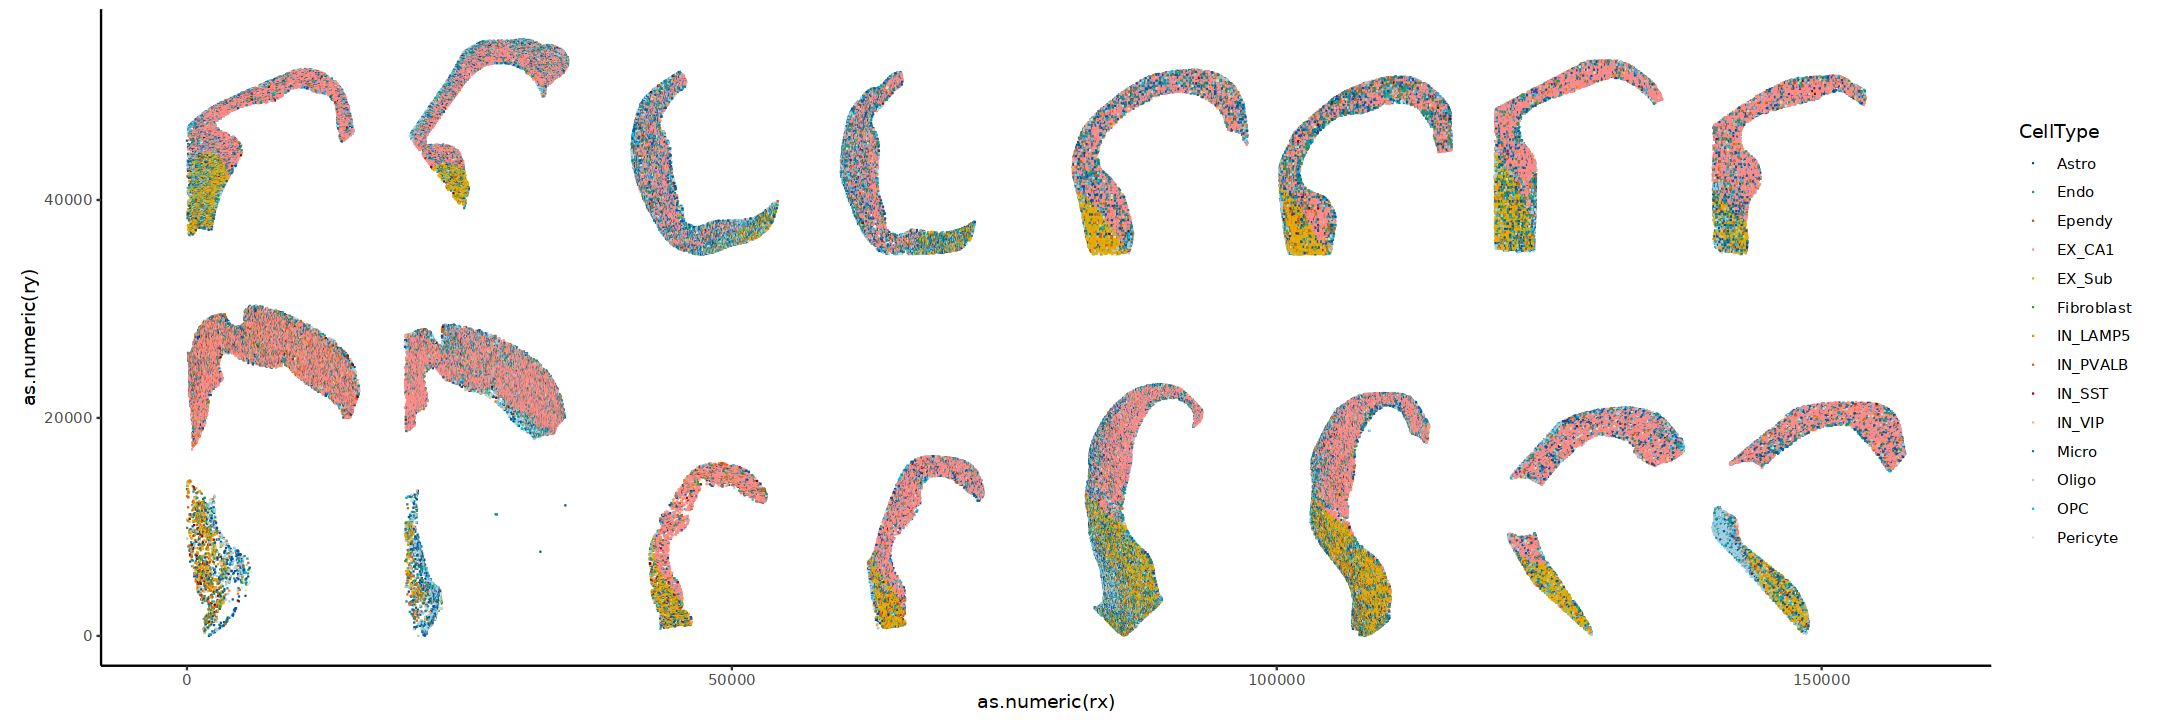

In [10]:
options(repr.plot.width = 18,repr.plot.height = 6)
ggplot(data@meta.data ,aes(as.numeric(rx), as.numeric(ry), color= CellType ))+ 
  # geom_tile()+
  geom_point(size = 0.3,shape = 15) +  # 设置点的大小和形状
  # scale_shape_manual(values = 18 ) +  # 手动设置每个组的形状
  theme_classic()+
  coord_fixed()+ 
  scale_color_manual(values =best_color)
ggsave('24chips-cellbin_CA1-Sub_noline.png',width = 40,height = 12)

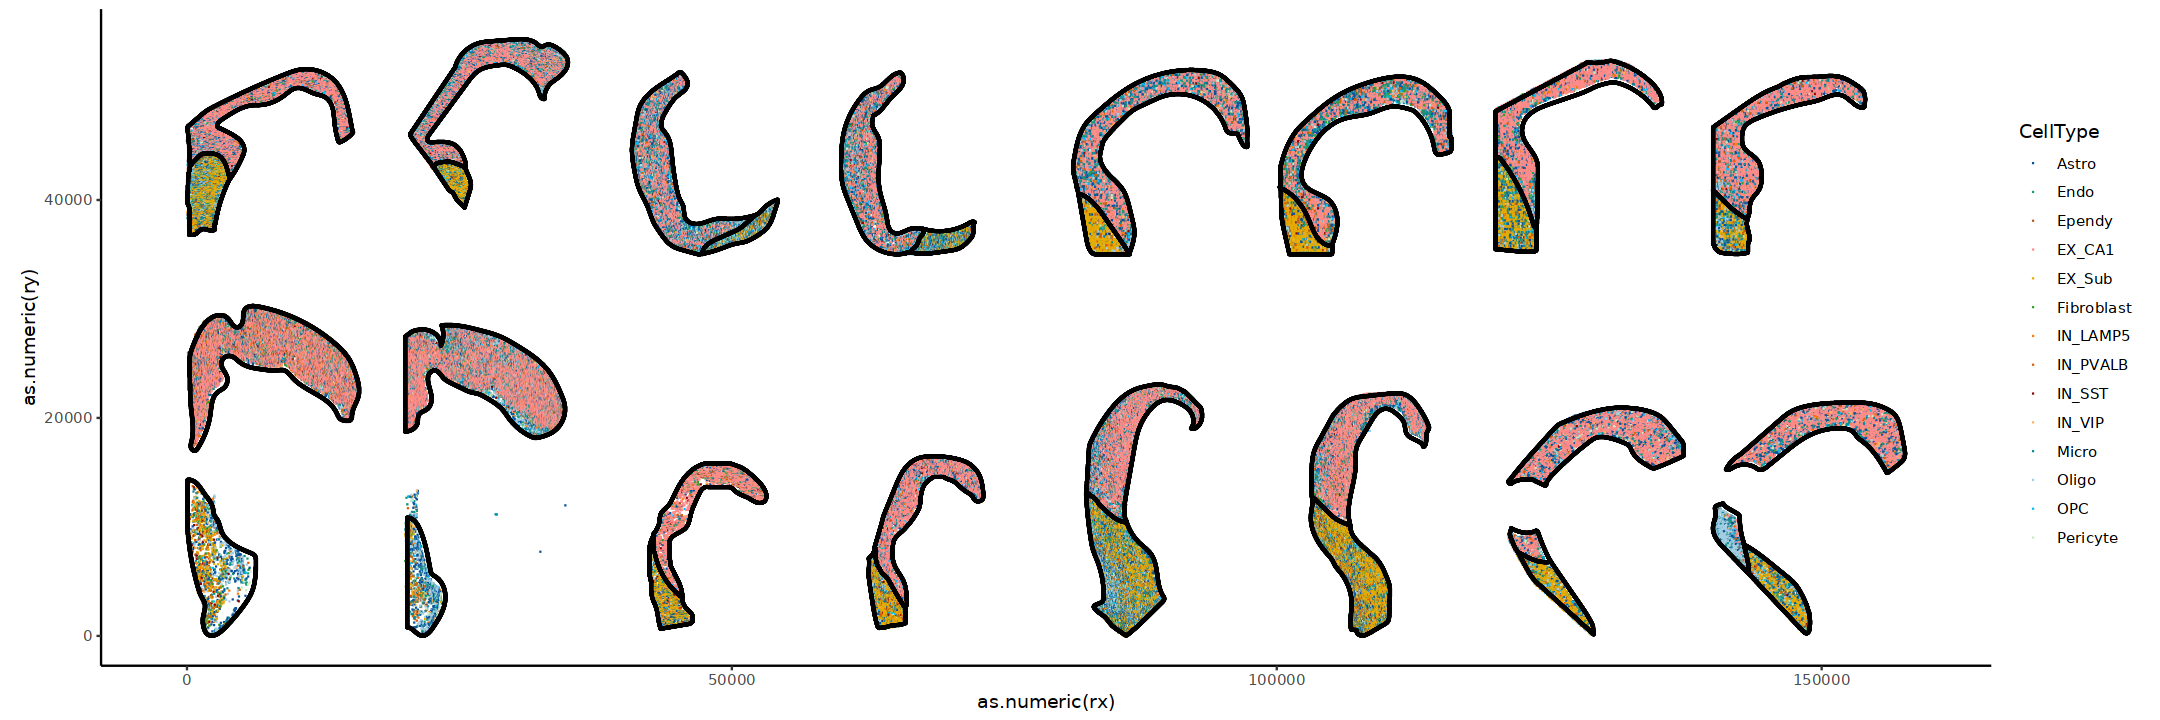

In [8]:
options(repr.plot.width = 18,repr.plot.height = 6)
ggplot(data@meta.data ,aes(as.numeric(rx), as.numeric(ry), color= CellType ))+ 
  # geom_tile()+
  geom_point(size = 0.3,shape = 15) +  # 设置点的大小和形状
  # scale_shape_manual(values = 18 ) +  # 手动设置每个组的形状
  theme_classic()+
  coord_fixed()+ 
  scale_color_manual(values =best_color)+
geom_point(data = line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")
ggsave('24chips-cellbin_CA1-Sub.png',width = 40,height = 12)

In [6]:
head(line)

,coor_x,coor_y,area,sample
,<dbl>,<dbl>,<chr>,<chr>
AD2_1.1,10609.81,52019,line,AD2_1
AD2_1.2,10625.41,52019,line,AD2_1
AD2_1.3,10641.01,52019,line,AD2_1
AD2_1.4,10656.61,52019,line,AD2_1
AD2_1.5,10672.22,52019,line,AD2_1
AD2_1.6,10687.82,52019,line,AD2_1


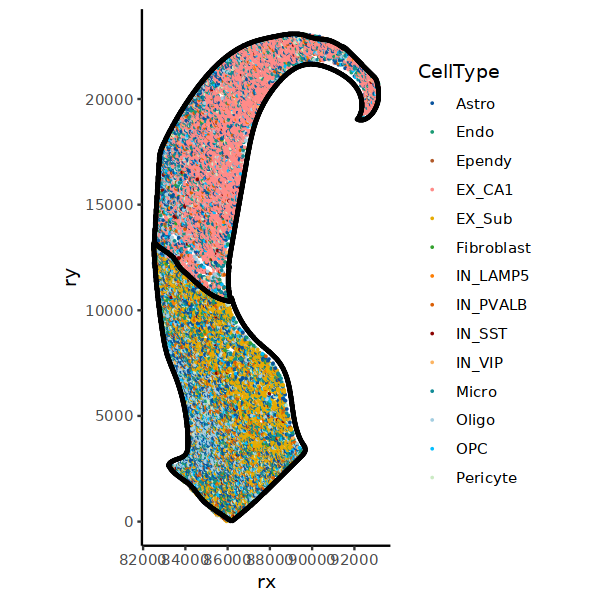

In [12]:
#####Con3.2 示意图
options(repr.plot.width = 5, repr.plot.height = 5)
Con = subset(data,chip=='Con3.1')
line1 = subset(line,sample=='Con3_1')

p1 <-  ggplot(Con@meta.data,aes(x = rx, y = ry, color = CellType))+
geom_point(size = 0.001) +
scale_color_manual(values = best_color) + 
theme_classic()+ coord_fixed()+ geom_point(data = line1, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

p1
# ggsave('24chips_CA1-Sub.pdf',width = 60,height = 8)

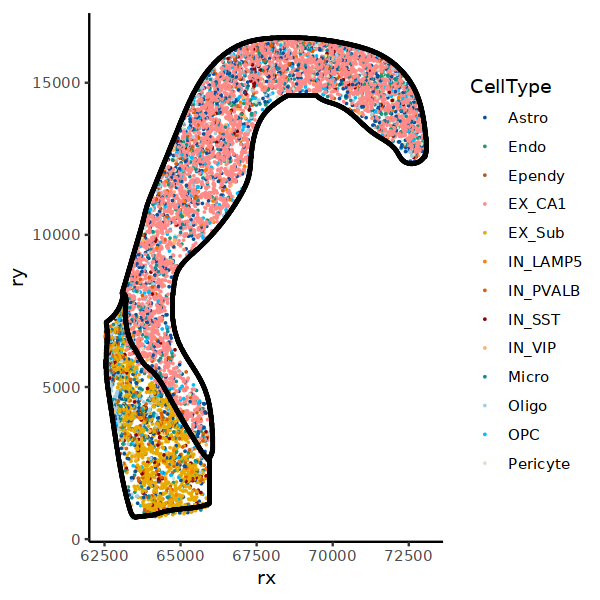

In [13]:
#####Con3.2 示意图
options(repr.plot.width = 5, repr.plot.height = 5)
Con = subset(data,chip=='Con2.2')
line1 = subset(line,sample=='Con2_2')

p1 <-  ggplot(Con@meta.data,aes(x = rx, y = ry, color = CellType))+
geom_point(size = 0.001) +
scale_color_manual(values = best_color) + 
theme_classic()+ coord_fixed()+ geom_point(data = line1, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

p1
# ggsave('24chips_CA1-Sub.pdf',width = 60,height = 8)

In [8]:
unique(meta$chip)

[1] "AD2.1"  "AD2.2"  "AD4.1"  "AD4.2"  "AD6.1"  "AD6.2"  "AD7.1"  "AD7.2" 
 [9] "Con1.1" "Con1.2" "Con2.1" "Con2.2" "Con3.1" "Con3.2" "Con8.1" "Con8.2"


 CA1_AD CA1_Con  Sub_AD Sub_Con 
  70946  100409   23024   37427 

,celltype,Group,ratio
,<fct>,<fct>,<dbl>
1,EX_CA1,CA1_Con,0.61946638
2,EX_Sub,CA1_Con,0.00000000
3,IN_LAMP5,CA1_Con,0.01162246
4,IN_PVALB,CA1_Con,0.04461751
5,IN_SST,CA1_Con,0.01121413
6,IN_VIP,CA1_Con,0.01615393


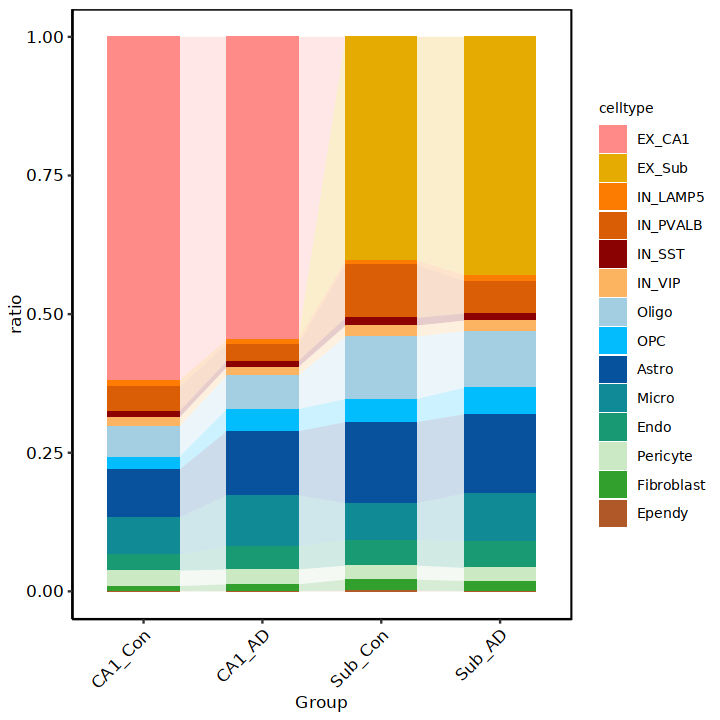

In [11]:
###比例差异
meta = data@meta.data
meta$group1 = paste0(meta$area,'_',meta$group)
table(meta$group1)
##########EX IN比例
 mytheme = theme(plot.title = element_text(size = 12,color="black",hjust = 0.5),
                 axis.title = element_text(size = 10,color ="black"),
                 axis.text = element_text(size=10,color = "black"),
                 #axis.line = element_line(color = "black"),
                 #axis.ticks = element_line(color = "black"),
                 panel.grid.minor.y = element_blank(),
                 panel.grid.minor.x = element_blank(),
                 # panel.grid=element_blank(), # 去网格线
                 # legend.position = "none",
                 legend.text = element_text(size=8),
                 legend.title= element_text(size= 8),
                 axis.text.x = element_text(angle = 45, hjust=1, vjust=1)
)
library(ggalluvial)
meta = data@meta.data
vector <- c('AD2.1', 'AD2.2', 'AD4.1', 'AD4.2', 'AD7.1', 'AD7.2', 
            'Con1.1', 'Con1.2','Con2.1', 'Con2.2', 'Con3.1', 'Con3.2', 'Con8.1', 'Con8.2')# 'AD6.1', 'AD6.2', 

meta = meta[meta$chip%in%vector,]
meta$group1 = paste0(meta$area,'_',meta$group)
meta$group1 = factor(meta$group1, levels=  c('CA1_Con','CA1_AD','Sub_Con','Sub_AD'))
meta$CellType = factor(meta$CellType, levels=  c('EX_CA1','EX_Sub',
                                                  'IN_LAMP5','IN_PVALB',"IN_SST",'IN_VIP',
                                                  "Oligo","OPC","Astro","Micro",
                                                  'Endo','Pericyte','Fibroblast','Ependy'))
Cellratio <- prop.table(table(meta$CellType, meta$group1), margin = 2)#计算各组样本不同细胞群比例
Cellratio <- as.data.frame(Cellratio)

colnames(Cellratio) <- c("celltype","Group","ratio") #对列名重命名
# Cellratio$celltype = factor(Cellratio$celltype,levels = c('Excitatory neurons','Inhibitory neurons'))
head(Cellratio)
options(repr.plot.width = 6, repr.plot.height = 6)

ggplot(Cellratio,aes(x=Group,y=ratio,fill=celltype,stratum=celltype,alluvium=celltype))+
       geom_col(width = 0.6,color=NA)+
       geom_flow(width=0.6,alpha=0.2,knot.pos=0)+ # knot.pos参数可以使连线变直
       scale_fill_manual(values=best_color)+
       theme_classic()+
       theme(panel.border = element_rect(fill=NA,color="black", size=0.5, linetype="solid"))+mytheme
       # theme(legend.position = 'none') #取消图例展示
ggsave(paste0("/data/work/脑区划分/01_result/CA1_Sub-cellbin比例.pdf"),width = 6, height = 6)

In [ ]:
###密度计算
###计算bin100数量
celldata = readRDS('/data/work/09_FigureV3/result/allchipsbin100_metadata.rds')
library(reshape2) 
library(tidyr)   
contingency_table <- table(celldata$area, celldata$chip)

# Convert the contingency table to a data frame
contingency_df <- as.data.frame(contingency_table)
# Rename columns for clarity
colnames(contingency_df) <- c("area", "chip", "count")
long_format_df <- melt(contingency_df, id.vars = c("area", "chip"))
colnames(long_format_df)[1] = 'area'
head(long_format_df)
write.csv(long_format_df,'/data/work/脑区划分/00_data/area_counts.csv')


In [12]:
alldata = readRDS('/data/users/liuyuyang/online/08.脑区划分/02.result/01.bin100/bin.AD_all32chips.CA1_Sub.250217.rds')
chiplist =c("Con1.1","Con1.2","AD4.1","AD4.2","Con2.1","Con2.2","Con3.1","Con3.2","AD2.1","AD2.2",
            "Con5.2","AD5.1","AD5.2","Con5.1","Con6.1","Con6.2","Con8.1","Con8.2","AD6.1","AD6.2","AD7.1","AD7.2","AD8.1","AD8.2")#
length(chiplist)
alldata = subset(alldata,sample%in%chiplist)


[1] 24

In [ ]:
###差异基因 jaccrd index



In [1]:
genlist = read.table('/data/users/liuyuyang/online/08.脑区划分/02.result/02.cellbin/05.AD/01.DEG/01.AD_Con.DEG.allmarkers.txt',header = TRUE)
# genlist = genlist[genlist$avg_log2FC>0.15&genlist$p_val_adj<0.05,]
genlist = genlist[genlist$p_val_adj<0.05,]
module = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
brown_genes = module[module$module=='brown',]$gene_name


In [2]:
brown_genes

[1] "CALM2"      "TMSB10"     "NDUFA4"     "COPS9"      "COX6C"     
  [6] "COX8A"      "DYNLL1"     "PPIA"       "COX7C"      "NDUFB1"    
 [11] "ATP5F1E"    "SOD1"       "TUBB4B"     "NDUFS5"     "COX5B"     
 [16] "TMA7"       "NDUFB4"     "SLC25A4"    "ATP5MF"     "PET100"    
 [21] "COX4I1"     "NDUFA1"     "LDHB"       "NDUFB3"     "RPL35A"    
 [26] "ISCU"       "NDUFB11"    "PGAM1"      "RPS26"      "COX6B1"    
 [31] "COX7A2"     "BEX3"       "ATP5MPL"    "MRPL33"     "EDF1"      
 [36] "ATP5PD"     "COX7B"      "UBL5"       "FKBP2"      "NDUFA13"   
 [41] "ATP5MD"     "COX6A1"     "ELOB"       "SLIRP"      "ATP5PF"    
 [46] "PARK7"      "AC005943.1" "OST4"       "AC010197.2" "AL133352.1"
 [51] "SELENOH"    "UQCRB"      "GADD45GIP1" "TXN"        "UQCRQ"     
 [56] "MRPL57"     "NHP2"       "UQCR11"     "POLR2L"     "UQCRH"     
 [61] "ALDOA"      "SRP14"      "AC024592.3" "NDUFB7"     "ATP5ME"    
 [66] "MRPL41"     "NDUFC1"     "SEC61G"     "MRPS21"     "RPL15"     
 [71] "HINT1"      "UQCR10"     "TBCA"       "NDUFB2"     "NAA38"     
 [76] "SELENOM"    "ATP5F1D"    "EIF1B"      "AURKAIP1"   "AP001267.5"
 [81] "NDUFA8"     "NDUFB6"     "TOMM7"      "SNU13"      "ARL3"      
 [86] "SMIM26"     "DYNLRB1"    "ATP5MG"     "MICOS10"    "ATP5PO"    
 [91] "REX1BD"     "PSMA7"      "BOLA3"      "TCEAL2"     "COX17"     
 [96] "YPEL3"      "COA6"       "SLC25A5"    "GPX4"       "PAIP2"     
[101] "NDUFA12"    "POLR2K"     "ANAPC11"    "MTLN"       "SF3B5"     
[106] "NDUFB10"    "MICOS13"    "BEX5"       "CYCS"       "ALKBH7"    
[111] "MGST3"      "NME1-NME2"  "PIN1"       "CYC1"       "NLRP1"     
[116] "PDCD5"      "SNRPD2"     "PYURF"      "NDUFA2"     "AC091167.2"
[121] "COX5A"      "NDUFS6"     "NDUFAB1"    "NDUFAF2"    "GABARAPL2" 
[126] "LAMTOR5"    "ELOC"       "ATP5MC1"    "PSMB6"      "NDUFB8"    
[131] "LSM3"       "SNRPE"      "PRDX5"      "SAP18"      "TOMM5"     
[136] "SELENOW"    "PPIAP22"

In [127]:
head(genlist)
table(genlist$cluster)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,cluster,compare,max.pct,up.down
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,1.549641e-130,-0.4904786,0.003,0.203,8.334277e-126,LINC00486,CA1-OPC,AD-vs-Con,0.203,down
2,3.896720e-113,-0.6220786,0.003,0.177,2.095734e-108,HSPA1A,CA1-OPC,AD-vs-Con,0.177,down
3,1.818923e-95,-0.5617229,0.023,0.200,9.782531e-91,HSPA1B,CA1-OPC,AD-vs-Con,0.200,down
4,7.447779e-87,-0.5670736,0.037,0.214,4.005565e-82,DNAJB1,CA1-OPC,AD-vs-Con,0.214,down
5,1.127574e-78,-0.4037945,0.002,0.126,6.064320e-74,HSPA6,CA1-OPC,AD-vs-Con,0.126,down
6,9.186240e-61,-0.4048627,0.069,0.230,4.940544e-56,HSPH1,CA1-OPC,AD-vs-Con,0.230,down



     CA1-Astro       CA1-Endo     CA1-EX_CA1 CA1-Fibroblast   CA1-IN_LAMP5 
            54             35             29             17             46 
  CA1-IN_PVALB     CA1-IN_SST     CA1-IN_VIP      CA1-Micro      CA1-Oligo 
            23             24             30             43             15 
       CA1-OPC   CA1-Pericyte      Sub-Astro       Sub-Endo     Sub-Ependy 
            62             88             22             17              4 
    Sub-EX_Sub Sub-Fibroblast   Sub-IN_LAMP5   Sub-IN_PVALB     Sub-IN_SST 
            92              8              4             80             11 
    Sub-IN_VIP      Sub-Micro      Sub-Oligo        Sub-OPC   Sub-Pericyte 
            20             13             16             12             49 

In [129]:
library(dplyr)


# 提取每个cluster中的唯一基因列表
cluster_gene_list <- genlist %>%
  group_by(cluster) %>%
  summarise(genes = list(unique(gene)), .groups = "drop")

jaccard_index <- function(set1, set2) {
  intersection <- length(intersect(set1, set2))
  union <- length(union(set1, set2))
  if (union == 0) return(0) # 避免除零错误
  intersection / union
}
result <- cluster_gene_list %>%
  rowwise() %>%
  mutate(
    jaccard = jaccard_index(unlist(genes), brown_genes)
  ) %>%
  select(cluster, jaccard) %>%
  arrange(-jaccard) # 按相似度降序排序



library(tidyr)

# 按规则拆分cluster列
result <- result %>%
  separate(
    col = "cluster",
    into = c("area", "celltype"),
    sep = "-", # 按第一个"-"拆分
    extra = "merge" # 防止多余内容报错
  )  


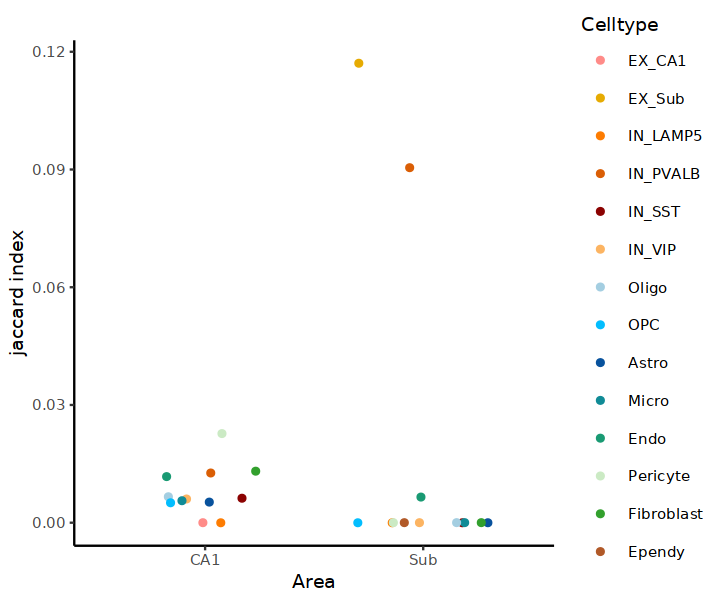

In [146]:
options(repr.plot.width = 6, repr.plot.height = 5)   ## 图像界面宽度显示设置
result$celltype = factor(result$celltype, levels=  c('EX_CA1','EX_Sub',
                                                  'IN_LAMP5','IN_PVALB',"IN_SST",'IN_VIP',
                                                  "Oligo","OPC","Astro","Micro",
                                                  'Endo','Pericyte','Fibroblast','Ependy'))
# Plot the scatter plot with jitter and highlight top 3 points
ggplot(result, aes(x = area, y = jaccard, color = celltype)) + 
  geom_point(size = 8, alpha = 0) +  # Increased transparency
  scale_color_manual(values = best_color) +
  theme_classic() + 
  geom_jitter(width = 0.3) +  # Add jitter to points
  labs(title = " ",
       x = "Area",
       y = "jaccard index",
       color = "Celltype")
ggsave('/data/work/脑区划分/01_result/jaccard index.pdf',height =4,width = 5)

In [11]:
####brown module 富集程度
module = read.csv('/data/work/脑区划分/01_result/Sub_CA1.Module.csv')
genelist = module[module$module=='brown',]$gene_name

In [12]:
gene_list <- list(genelist)
data_n <- AddModuleScore( object = data, 
                         nbin = 12,
                         features = gene_list, 
                         ctrl = 100, #默认值是100 
                         name = 'moudle')

In [13]:
head(data_n)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,percent.mt,cellid,chip,CellType,CellType_sub,⋯,SCT_snn_res.0.8,SCT_snn_res.1.2,SCT_snn_res.2,seurat_clusters,coor_y,coor_x,xy,CellType_batch4_m,group,moudle1
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>
22084_3,Spatial,222,133,222,133,3.153153,22084,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.02797814
22086_3,Spatial,150,101,150,101,2.666667,22086,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.04055682
22097_3,Spatial,229,142,229,142,3.930131,22097,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.01196921
22098_3,Spatial,764,405,764,405,1.308901,22098,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.28294364
22100_3,Spatial,245,163,245,163,2.448980,22100,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.01460492
22114_3,Spatial,231,147,231,147,6.060606,22114,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.05043277
22115_3,Spatial,1037,565,1037,565,2.410800,22115,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.19901560
22116_3,Spatial,253,160,253,160,3.162055,22116,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.02277851
22124_3,Spatial,281,161,281,161,4.270463,22124,AD2.1,Micro,Micro,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.03832476


Warning message in (function (mapping = NULL, data = NULL, stat = "ydensity", position = "dodge", :
“Ignoring unknown aesthetics: scale”


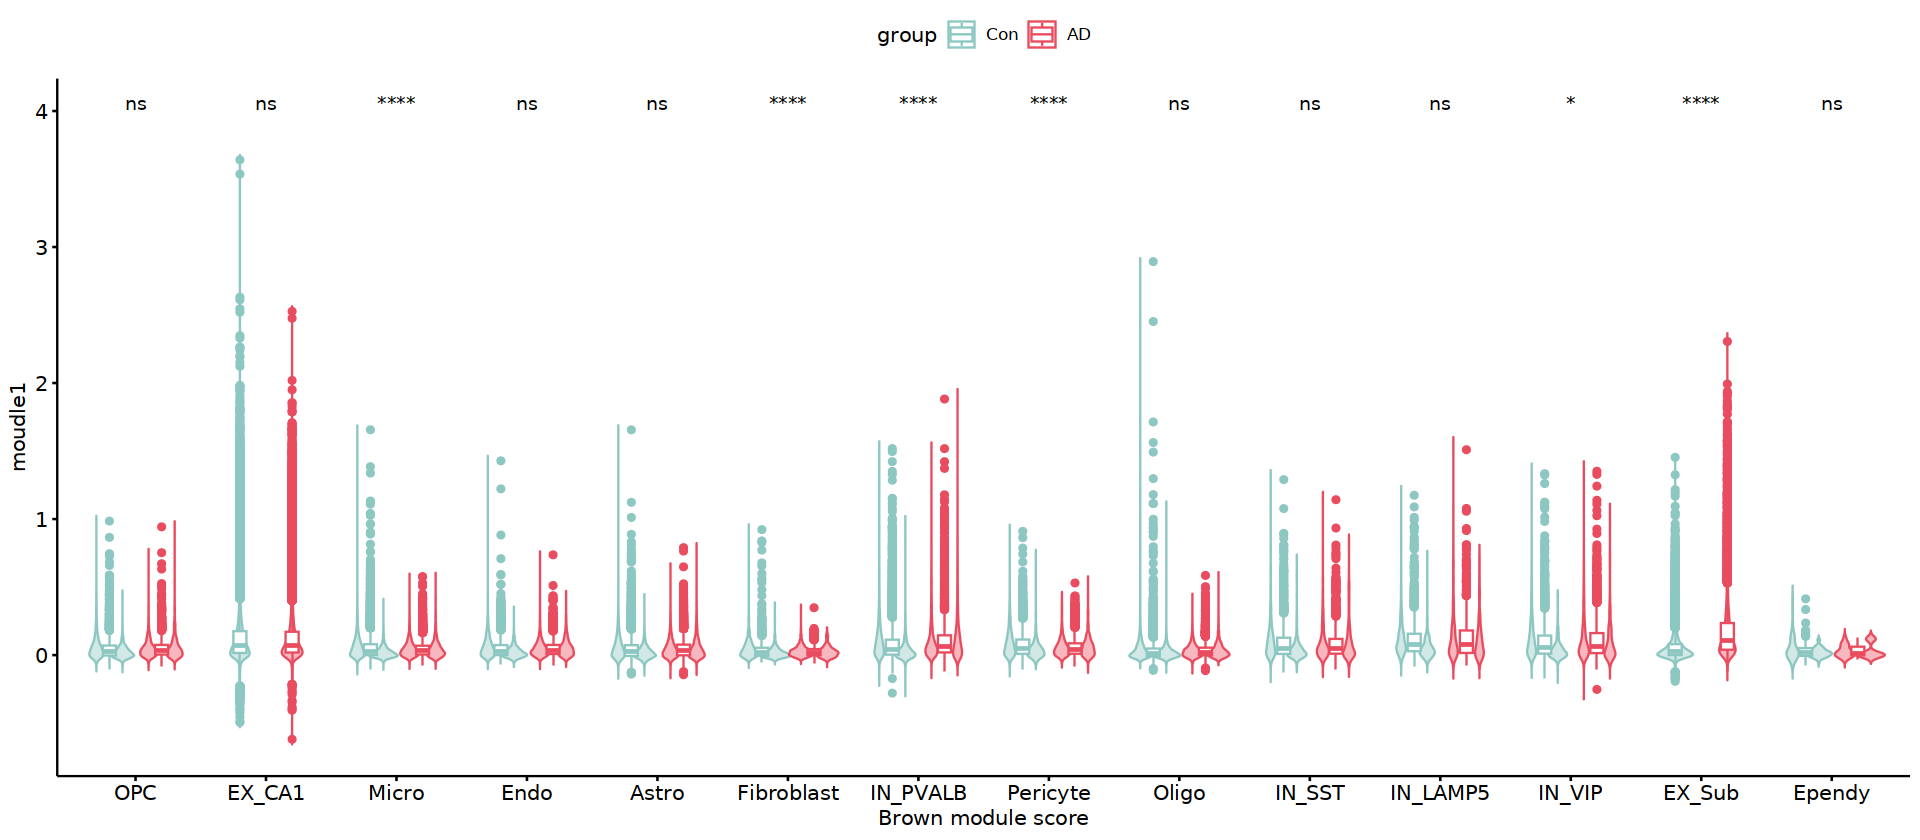

In [19]:

result = data_n@meta.data
options(repr.plot.width = 16, repr.plot.height = 7)   ## 图像界面宽度显示设置
cols = c("#8dc7c2", "#e94c5f")
library(ggplot2)
library(reshape2)
library(ggpubr)
library(ggsignif)  #添加显著性标记
# 将 sample 转换为因子，并指定顺序
result$group = factor(result$group, levels = c('Con', 'AD'))

mycolor = c("#8dc7c2", "#e94c5f")
p1 <- ggviolin(result, x = "CellType",
y = "moudle1",
color = "group",
fill = "group",
alpha =0.4,
width=0.9,
add = "boxplot",add.params = list(fill = "white"))+
guides(fill = "none")+
xlab('Brown module score')+
scale_colour_manual(values=alpha(mycolor,1))+
scale_fill_manual(values=alpha(mycolor,0.5))+ 
stat_compare_means(aes(x = CellType, y = moudle1, group = group), 
                       data = result, method = "t.test", 
                       label = "p.signif", 
                       label.y = max(result$moudle1) * 1.1)

p1

# 如果需要保存图形，可以使用 ggsave
# ggsave("/data/work/脑区划分/01_result/brown1_cellbin.pdf", height = 5, width = 7)


In [57]:
matrix = result[,c('chip','CellType','area','group','moudle1')]
result1 <- matrix %>%
  group_by(group, CellType, area) %>%
  summarise(mean_moudle1 = mean(moudle1, na.rm = TRUE))

# 查看结果
head(result1)

`summarise()` has grouped output by 'group', 'CellType'. You can override using
the `.groups` argument.


group,CellType,area,mean_moudle1
<fct>,<chr>,<chr>,<dbl>
Con,Astro,CA1,0.06225219
Con,Astro,Sub,0.01798598
Con,EX_CA1,CA1,0.13397876
Con,EX_Sub,Sub,0.05799081
Con,Endo,CA1,0.06366983
Con,Endo,Sub,0.02146209


Warning message in heatmap_data$chip = NULL:
“Coercing LHS to a list”


Adding missing grouping variables: `group`
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `group = .Primitive("as.double")(group)`.
Caused by warning:
! NAs introduced by coercion”


[1] TRUE

png 
  2

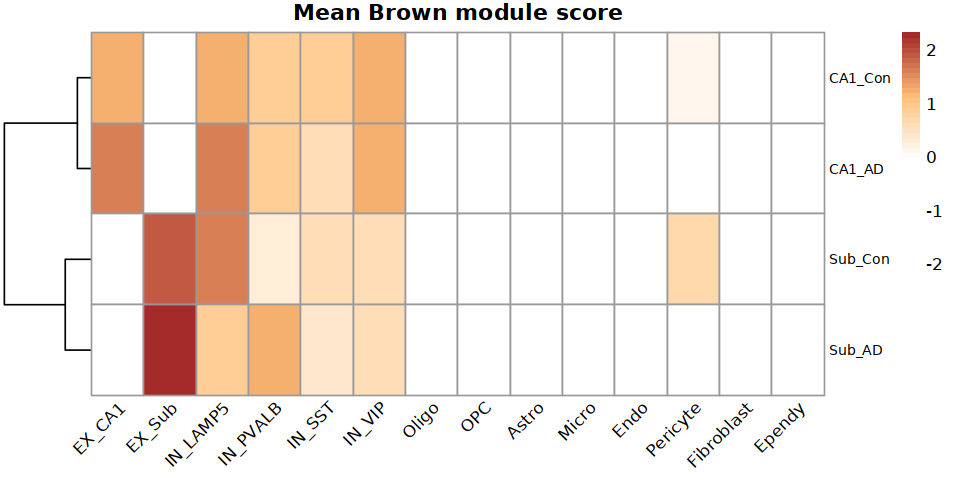

In [83]:
library(pheatmap)
library(tidyr)
options(repr.plot.width = 8, repr.plot.height = 4)   ## 图像界面宽度显示设置

# 正确合并行名并转换数据（无需删除列）
heatmap_matrix <- result1 %>%
  mutate(row_id = paste(area, group, sep = "_")) %>%  # 合并area和chip为行名
  select(row_id, CellType, mean_moudle1) %>%
  pivot_wider(names_from = CellType, values_from = mean_moudle1, values_fill = 0) %>% 
  column_to_rownames("row_id") %>%  # 直接设置行名
  as.matrix() %>% 
  as.data.frame() %>%  # 转换为数据框
  mutate_all(as.numeric)  # 确保所有列为数值型
heatmap_matrix$group = NULL
order1 = c('EX_CA1','EX_Sub',
          'IN_LAMP5','IN_PVALB',"IN_SST",'IN_VIP',
          "Oligo","OPC","Astro","Micro",
          'Endo','Pericyte','Fibroblast','Ependy')
heatmap_matrix = heatmap_matrix[,order1]
nrow(heatmap_matrix) == length(rownames(heatmap_matrix))  # 应返回TRUE
p = pheatmap(heatmap_matrix,scale = "row",
         # color = colorRampPalette(c("white", "white","white",'grey', "black"))(50),
           color = colorRampPalette(c("white", "white","white",'#FFC078', "brown"))(50),  
         cluster_rows = TRUE, cluster_cols = FALSE,
         main = "Mean Brown module score",
         angle_col = 45, fontsize_row = 8, fontsize_col = 10)
save_pheatmap_pdf <- function(x, filename, width=8, height=4) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   pdf(filename, width=width, height=height)
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}
save_pheatmap_pdf(p,filename='Mean Brown module score.pdf')



In [147]:
##spatial plot

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,percent.mt,cellid,chip,CellType,CellType_sub,⋯,SCT_snn_res.0.8,SCT_snn_res.1.2,SCT_snn_res.2,seurat_clusters,coor_y,coor_x,xy,CellType_batch4_m,group,moudle1
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>
22084_3,Spatial,222,133,222,133,3.153153,22084,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.02797814
22086_3,Spatial,150,101,150,101,2.666667,22086,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.04055682
22097_3,Spatial,229,142,229,142,3.930131,22097,AD2.1,OPC,OPC,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.01196921
22098_3,Spatial,764,405,764,405,1.308901,22098,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.28294364
22100_3,Spatial,245,163,245,163,2.448980,22100,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.01460492
22114_3,Spatial,231,147,231,147,6.060606,22114,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.05043277
22115_3,Spatial,1037,565,1037,565,2.410800,22115,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.19901560
22116_3,Spatial,253,160,253,160,3.162055,22116,AD2.1,EX_CA1,EX_CA1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,-0.02277851
22124_3,Spatial,281,161,281,161,4.270463,22124,AD2.1,Micro,Micro,⋯,NA,NA,NA,NA,NA,NA,NA,NA,AD,0.03832476


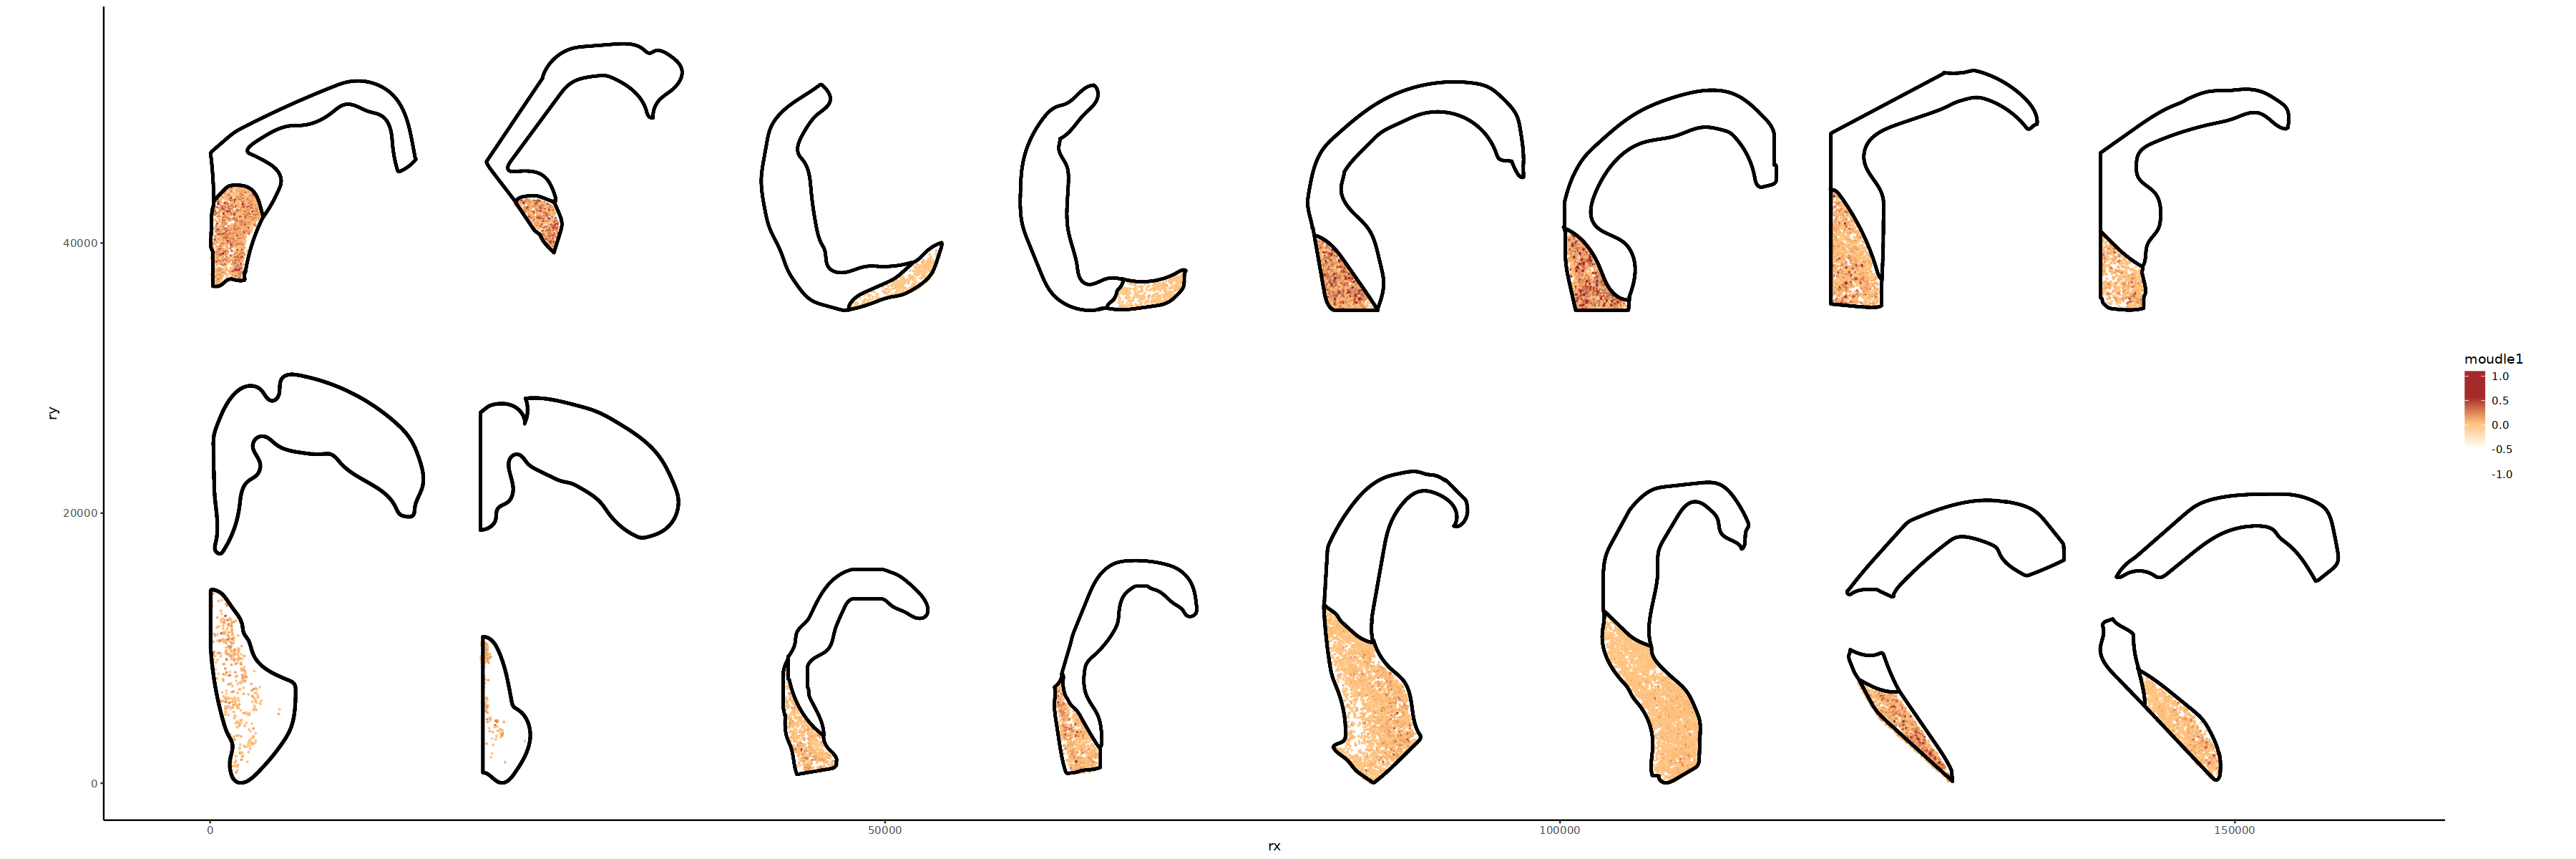

In [177]:
options(repr.plot.width = 30, repr.plot.height = 10)
# 若需要强调高表达区域，可调整颜色权重
cols = colorRampPalette(c("white","white", "#FFC078",  "brown","brown"))(100)

# Subset the data for Con3.1 and line data for Con3_1
Con = subset(data_n, CellType=='EX_Sub')#chip == 'Con3.1'&

# Create the plot
p1 <- ggplot(Con@meta.data, aes(x = rx, y = ry, color = moudle1)) +
  geom_point(size = 0.001) +
  scale_color_gradientn(colors = cols, limits = c(-1, 1.1)) +  # Set color scale limits to 0-0.5
  theme_classic() + 
  coord_fixed() + 
  geom_point(data = line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

# Display the plot
p1

# Save the plot if needed
ggsave('24chips_CA1-Sub-brown-cellbin.pdf', width = 50, height = 8,limitsize = FALSE)


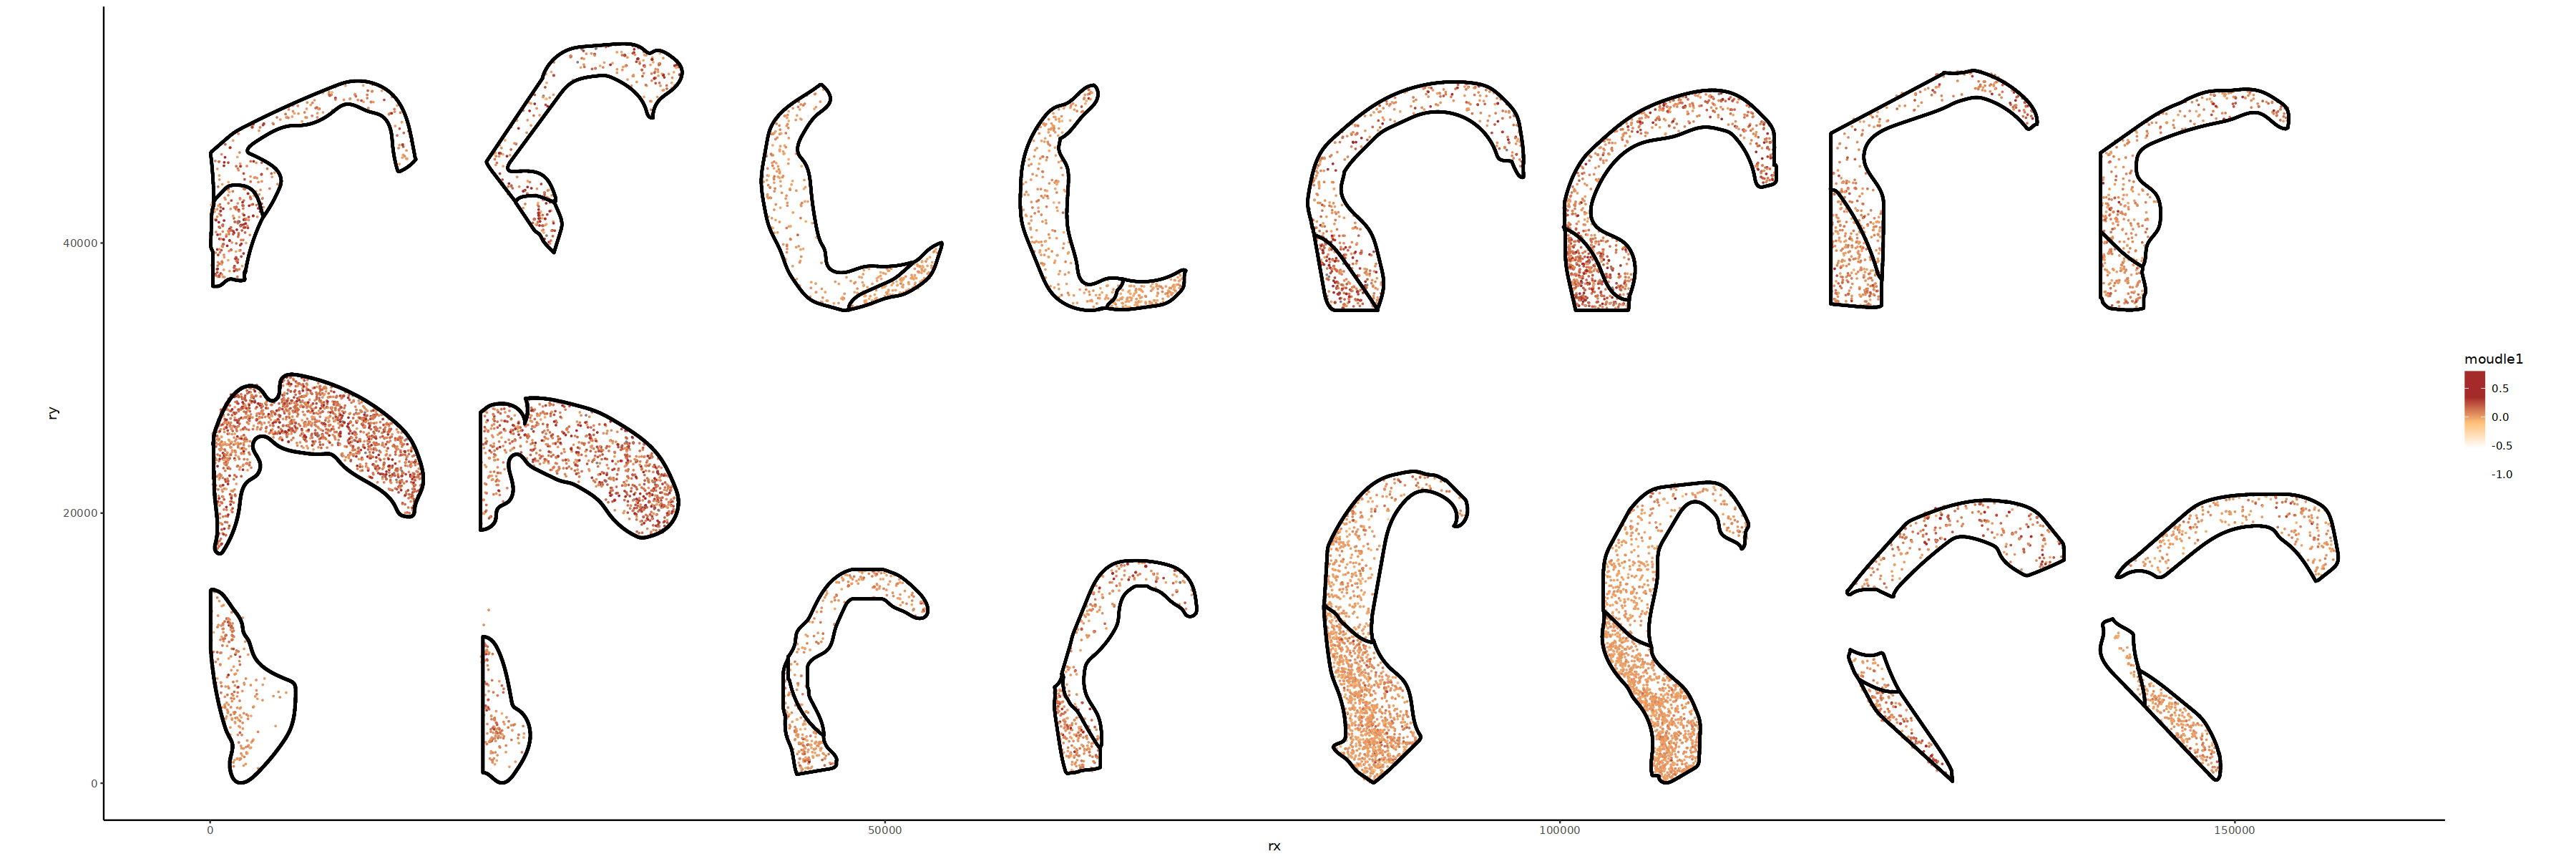

In [179]:
options(repr.plot.width = 30, repr.plot.height = 10)
# 若需要强调高表达区域，可调整颜色权重
cols = colorRampPalette(c("white","white", "#FFC078",  "brown","brown"))(100)

# Subset the data for Con3.1 and line data for Con3_1
Con = subset(data_n, CellType=='IN_PVALB')#chip == 'Con3.1'&

# Create the plot
p1 <- ggplot(Con@meta.data, aes(x = rx, y = ry, color = moudle1)) +
  geom_point(size = 0.001) +
  scale_color_gradientn(colors = cols, limits = c(-1, 0.8)) +  # Set color scale limits to 0-0.5
  theme_classic() + 
  coord_fixed() + 
  geom_point(data = line, aes(x = coor_x, y = coor_y), size = 0.000001, color = "black")

# Display the plot
p1

# Save the plot if needed
ggsave('24chips_CA1-Sub-brown-pvalb.pdf', width = 50, height = 8,limitsize = FALSE)


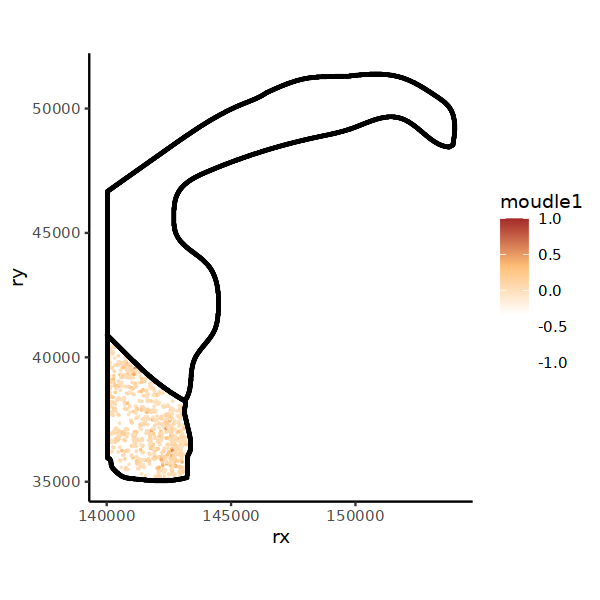

In [171]:
options(repr.plot.width = 5, repr.plot.height = 5)
# 若需要强调高表达区域，可调整颜色权重
cols = colorRampPalette(c("white", "white", "#FFC078", "brown"))(100)

# Subset the data for Con3.1 and line data for Con3_1
Con = subset(data_n, chip == 'AD7.2'&CellType=='EX_Sub')
line1 = subset(line, sample == 'AD7_2')

# Create the plot
p1 <- ggplot(Con@meta.data, aes(x = rx, y = ry, color = moudle1)) +
  geom_point(size = 0.001) +
  scale_color_gradientn(colors = cols, limits = c(-1, 1)) +  # Set color scale limits to 0-0.5
  theme_classic() + 
  coord_fixed() + 
  geom_point(data = line1, aes(x = coor_x, y = coor_y), size = 0.0001, color = "black")

# Display the plot
p1

# Save the plot if needed
# ggsave('24chips_CA1-Sub.pdf', width = 60, height = 8)
